# 01 — Data Loading and Exploration

**Dataset:** NIR Corn Spectra — 80 samples, 700 wavelength columns, 4 label columns (Moisture, Starch, Oil, Protein).

**Goal:** Load the raw dataset, look at its structure, check the label distributions, and visualize the raw spectra.

> No preprocessing, data splitting, or file saving is done in this notebook.

## 1. Imports and Setup

Import the four libraries we need: `pandas` for handling the data table, `numpy` for math, and `matplotlib` + `seaborn` for making charts. We also set a clean plot style here.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set a clean plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

Load the CSV file into a pandas DataFrame, check its shape, and look at the first few rows. Then separate the 700 spectral columns into `X` and the 4 label columns into `labels_df`.

In [14]:
df = pd.read_csv('../data/raw/corn_mp5_regression_data.csv')

print(f"Dataset shape: {df.shape}  (rows x columns)")
df.head()

Dataset shape: (80, 705)  (rows x columns)


,SampleID,Wave_1,Wave_2,Wave_3,Wave_4,Wave_5,Wave_6,Wave_7,Wave_8,Wave_9,...,Wave_695,Wave_696,Wave_697,Wave_698,Wave_699,Wave_700,Moisture,Starch,Oil,Protein
0,S001,-0.012440,-0.012514,-0.012550,-0.012519,-0.012468,-0.012356,-0.012190,-0.011983,-0.011684,...,0.684820,0.685216,0.685353,0.685223,0.684899,0.684377,10.448,3.687,8.746,64.838
1,S002,-0.014189,-0.014251,-0.014288,-0.014264,-0.014214,-0.014106,-0.013945,-0.013756,-0.013454,...,0.692659,0.693017,0.693037,0.692842,0.692377,0.691869,10.409,3.720,8.658,64.851
2,S003,-0.013373,-0.013439,-0.013476,-0.013456,-0.013413,-0.013314,-0.013167,-0.013003,-0.012724,...,0.663445,0.663723,0.663988,0.663755,0.663504,0.662983,10.313,3.496,9.125,63.567
3,S004,-0.016487,-0.016543,-0.016576,-0.016573,-0.016519,-0.016414,-0.016278,-0.016096,-0.015830,...,0.659993,0.660412,0.660627,0.660580,0.660190,0.659695,10.260,3.504,9.389,63.263
4,S005,-0.008495,-0.008567,-0.008597,-0.008566,-0.008515,-0.008388,-0.008219,-0.007997,-0.007666,...,0.728424,0.728744,0.728745,0.728585,0.728193,0.727811,10.292,3.661,8.952,64.148


In [15]:
# Separate the 700 wavelength columns and the 4 label columns
spectral_cols = [f'Wave_{i}' for i in range(1, 701)]
label_cols    = ['Moisture', 'Starch', 'Oil', 'Protein']

X         = df[spectral_cols]   # shape: (80, 700)
labels_df = df[label_cols]      # shape: (80, 4)

print(f"X shape       : {X.shape}  (samples x wavelength channels)")
print(f"labels_df shape: {labels_df.shape}  (samples x labels)")
print(f"\nLabel columns : {label_cols}")

X shape       : (80, 700)  (samples x wavelength channels)
labels_df shape: (80, 4)  (samples x labels)

Label columns : ['Moisture', 'Starch', 'Oil', 'Protein']


## 3. Descriptive Statistics

Use `.describe()` to get a quick summary of all four label columns. We also compute the **median protein value** — this will later be used as the threshold to define *High Protein* vs *Low Protein* classes.

In [16]:
print("Descriptive statistics for all four label columns:\n")
display(labels_df.describe().round(4))

median_protein = labels_df['Protein'].median()
print(f"\nMedian Protein value: {median_protein:.4f} %")

Descriptive statistics for all four label columns:



,Moisture,Starch,Oil,Protein
count,80.0000,80.0000,80.0000,80.0000
mean,10.2335,3.4984,8.6683,64.6956
std,0.3804,0.1770,0.4986,0.8207
min,9.3770,3.0880,7.6540,62.8260
25%,9.9560,3.4062,8.2875,64.2648
50%,10.2825,3.4965,8.5615,64.8220
75%,10.4655,3.6420,9.0188,65.3455
max,10.9930,3.8320,9.7110,66.4720



Median Protein value: 64.8220 %


## 4. Protein Distribution Plot

A histogram with a kernel density estimate (KDE) shows how protein values are spread across all 80 samples. The dashed vertical line marks the median — the value we will use as the classification threshold.

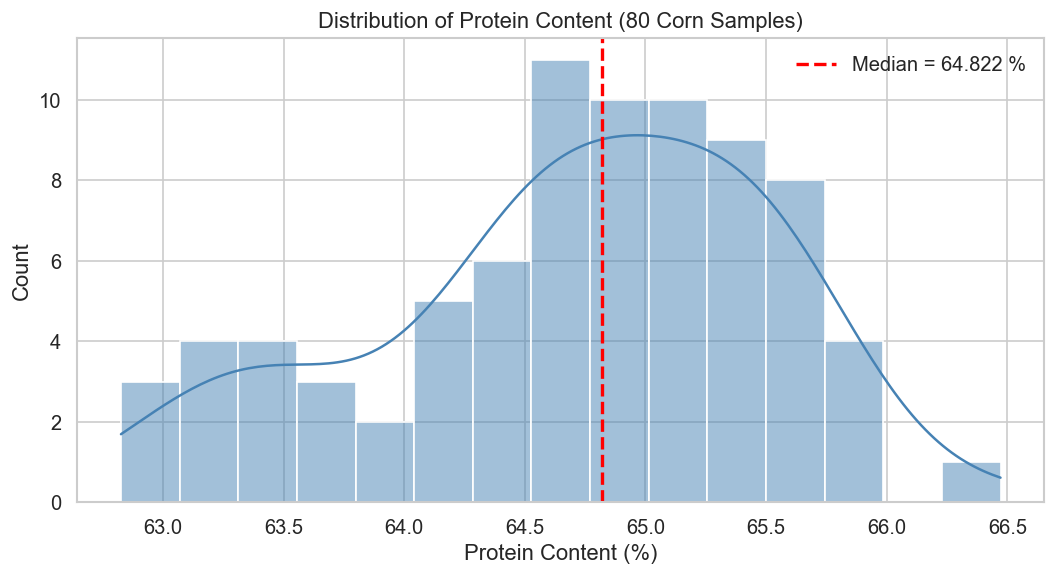

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    labels_df['Protein'],
    bins=15,
    kde=True,
    color='steelblue',
    edgecolor='white',
    ax=ax
)

ax.axvline(
    median_protein,
    color='red',
    linestyle='--',
    linewidth=2.0,
    label=f'Median = {median_protein:.3f} %'
)

ax.set_title('Distribution of Protein Content (80 Corn Samples)')
ax.set_xlabel('Protein Content (%)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Raw NIR Spectra Plot

Plot all 80 spectra on one figure. The x-axis is the actual wavelength in nm (1100–2498 nm), and the y-axis is absorbance. Using a low alpha makes overlapping lines easier to see.

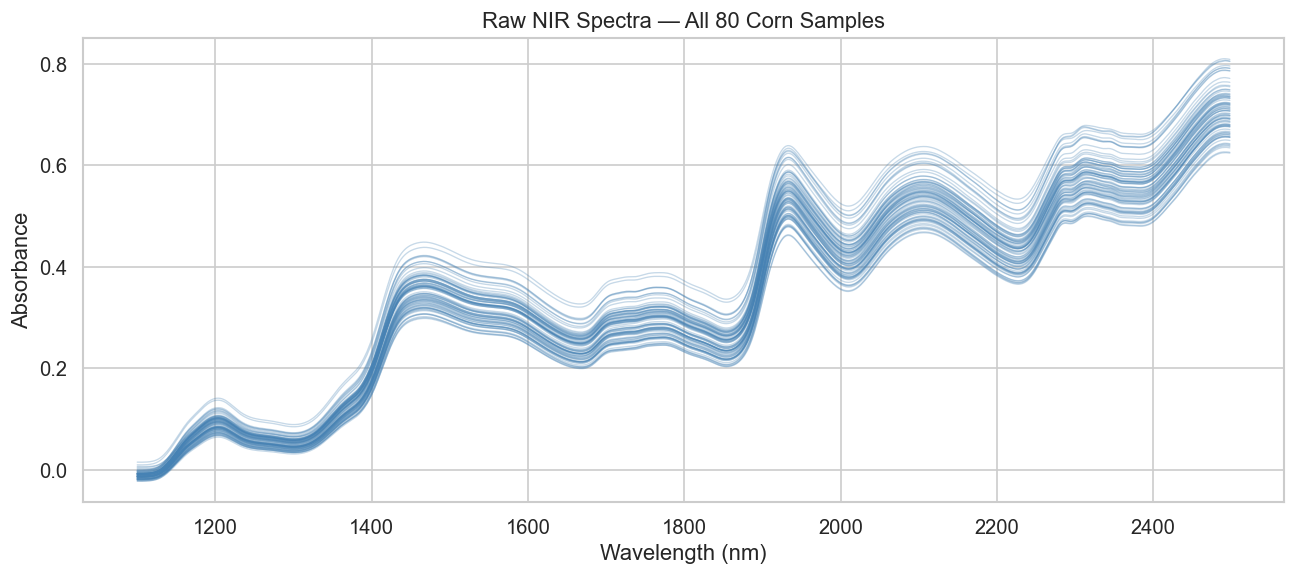

In [18]:
# Map the 700 column indices to actual wavelengths: 1100 nm to 2498 nm, step = 2 nm
wavelengths = np.arange(1100, 2499, 2)   # 700 points

fig, ax = plt.subplots(figsize=(11, 5))

for spectrum in X.values:
    ax.plot(wavelengths, spectrum, color='steelblue', alpha=0.3, linewidth=0.8)

ax.set_title('Raw NIR Spectra — All 80 Corn Samples')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')

plt.tight_layout()
plt.show()

## 6. Spectra Colored by Protein Group

Re-plot the spectra and color each one based on whether the sample's protein value is above or below the median:
- **Red** = High Protein (above median)
- **Blue** = Low Protein (at or below median)

> This is for visual exploration only — no labels are officially assigned here.

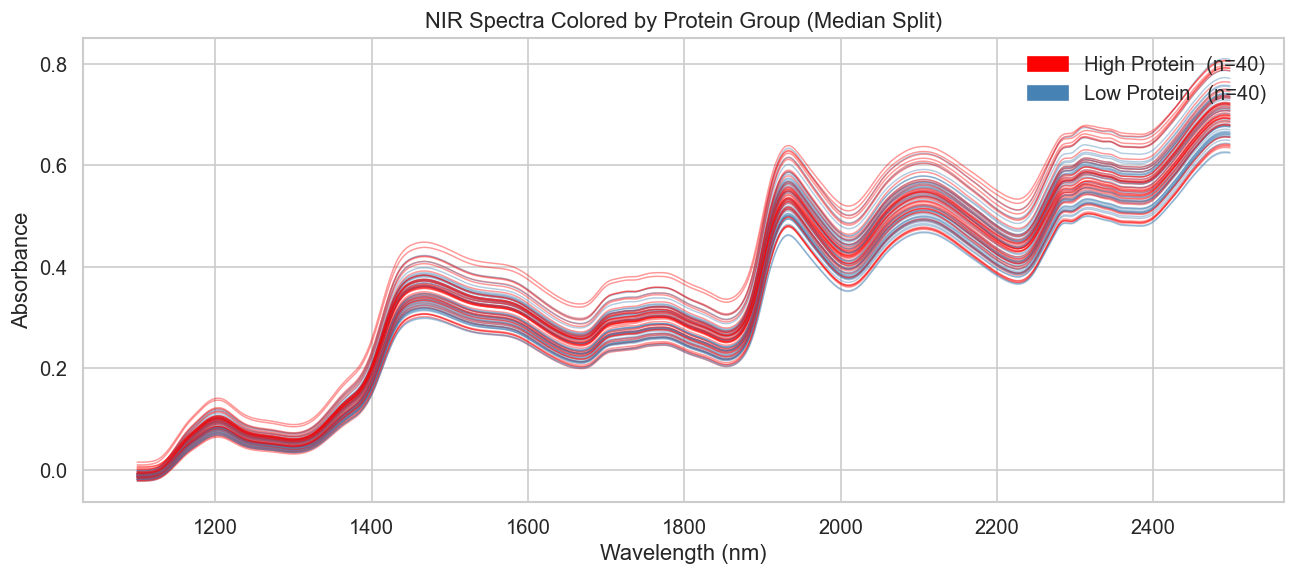

In [19]:
is_high_protein = labels_df['Protein'].values > median_protein

fig, ax = plt.subplots(figsize=(11, 5))

for spectrum, is_high in zip(X.values, is_high_protein):
    color = 'red' if is_high else 'steelblue'
    ax.plot(wavelengths, spectrum, color=color, alpha=0.4, linewidth=0.9)

high_patch = mpatches.Patch(color='red',       label=f'High Protein  (n={is_high_protein.sum()})')
low_patch  = mpatches.Patch(color='steelblue', label=f'Low Protein   (n={(~is_high_protein).sum()})')
ax.legend(handles=[high_patch, low_patch], loc='upper right')

ax.set_title('NIR Spectra Colored by Protein Group (Median Split)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')

plt.tight_layout()
plt.show()

## Summary

Here is what we found from this initial exploration:

- **Dataset shape:** 80 samples × 701 columns (1 ID + 700 wavelengths + 4 labels)
- **Spectral features:** 700 wavelength channels covering 1100 nm to 2498 nm (step = 2 nm)
- **Label columns found:** Moisture, Starch, Oil, Protein
- **Protein range:** values are spread enough to support a meaningful binary split
- **Median protein value** was computed and will serve as the classification threshold in the next notebook
- **Spectral patterns:** The colored spectra plot (Section 6) shows some visible differences between High Protein and Low Protein groups, especially in certain wavelength regions — this suggests the NIR signal carries useful information for classification

**Next step:** `02_labeling.ipynb` — assign official binary class labels (High Protein = 1, Low Protein = 0) based on the median threshold found here.